In [227]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [228]:
df=pd.read_csv('placement.csv')

In [229]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [231]:
df.isna().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [232]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [233]:
df.shape

(10000, 10)

In [234]:
df=df.drop(['College_ID','Prev_Sem_Result'],axis=1)

In [235]:
print(df['Placement'].value_counts())
print(df['Placement'].value_counts(normalize=True))

Placement
No     8341
Yes    1659
Name: count, dtype: int64
Placement
No     0.8341
Yes    0.1659
Name: proportion, dtype: float64


In [236]:
df['Placement'] = df['Placement'].map({'Yes': 1, 'No': 0})

<Axes: xlabel='CGPA', ylabel='Count'>

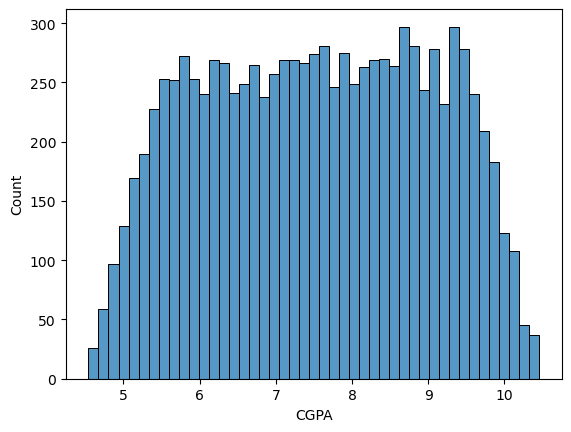

In [237]:
sns.histplot(df['CGPA'],bins=45)

<Axes: xlabel='Communication_Skills', ylabel='Count'>

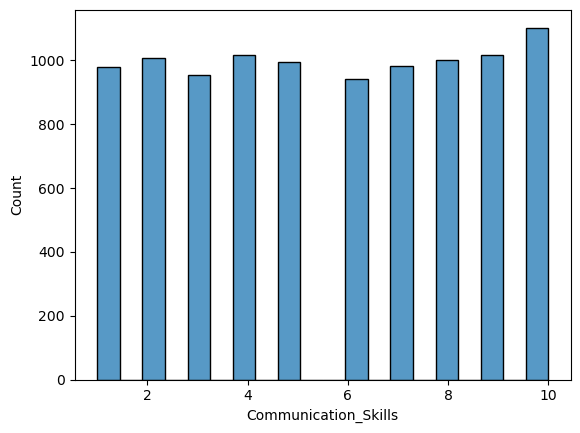

In [238]:
sns.histplot(df['Communication_Skills'])

<Axes: xlabel='Academic_Performance', ylabel='Placement'>

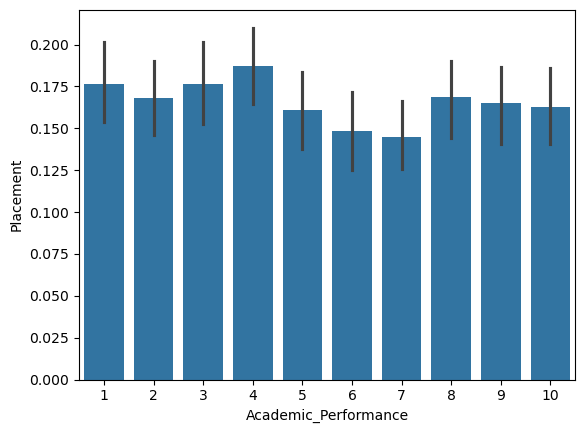

In [239]:
sns.barplot(x=df['Academic_Performance'],y=df['Placement'])

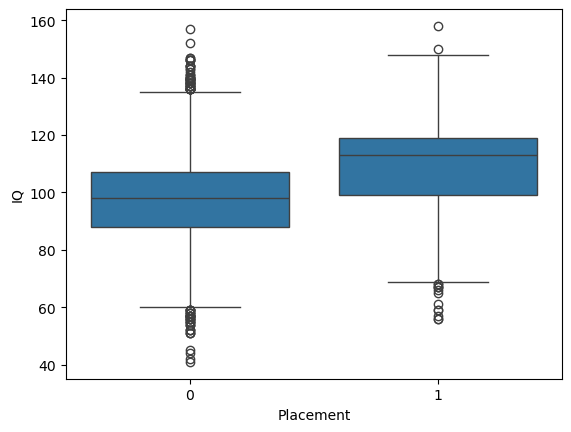

In [240]:
sns.boxplot(x='Placement', y='IQ', data=df)
plt.show()

<Axes: xlabel='Placement', ylabel='count'>

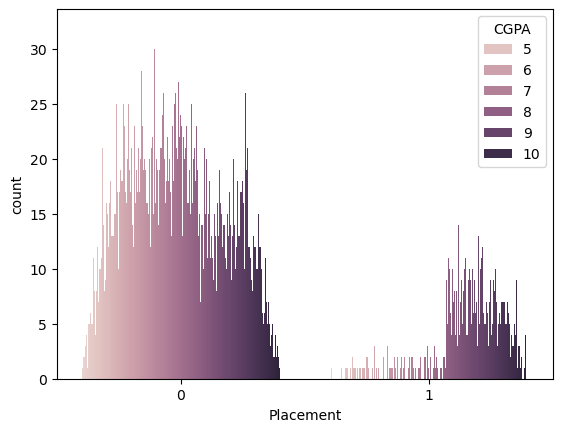

In [241]:
sns.countplot(x=df['Placement'],hue=df['CGPA'])

<Axes: >

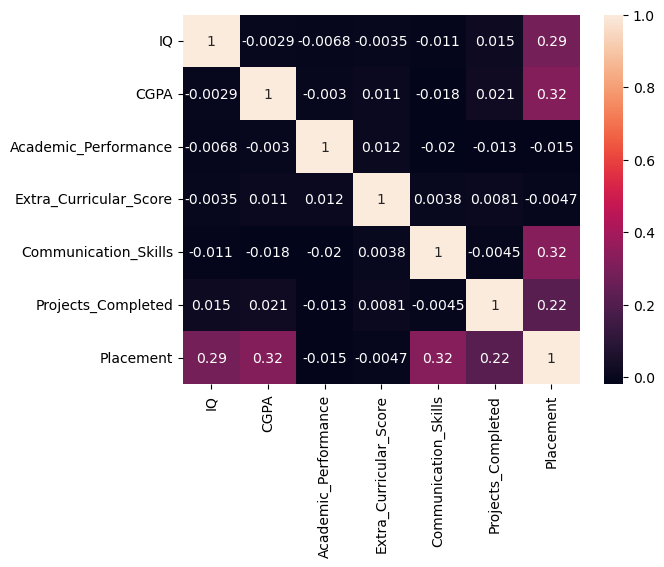

In [242]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [243]:
df = pd.get_dummies(
    df,
    columns=['Internship_Experience'],
    dtype=int
)


In [244]:
x=df.drop('Placement',axis=1)
y=df['Placement']


In [245]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
columns= ['IQ', 'CGPA', 'Academic_Performance', 'Extra_Curricular_Score', 'Communication_Skills','Projects_Completed']
x[columns]=scaler.fit_transform(x[columns])

In [246]:
x

,IQ,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Experience_No,Internship_Experience_Yes
0,0.500135,-0.851919,0.853921,0.958593,0.840550,0.866381,1,0
1,-0.164214,-1.470939,0.853921,0.642131,0.840550,-1.464794,1,0
2,0.633004,-1.158028,1.201949,-0.623713,-1.572644,-0.882000,1,0
3,1.496657,-1.212447,0.157865,-1.256636,0.151066,-0.882000,0,1
4,-0.230648,0.107220,0.505893,0.958593,1.530034,-0.299206,1,0
...,...,...,...,...,...,...,...,...
9995,1.297352,0.515365,-0.538190,-1.256636,0.840550,-1.464794,1,0
9996,-1.957954,1.229618,0.505893,-1.573097,0.495808,-0.299206,1,0
9997,-0.695692,-0.872327,-0.886218,-0.623713,1.185292,1.449175,0,1
9998,0.500135,0.943917,-0.886218,0.642131,-0.193676,-0.882000,1,0


In [247]:
x['Internship_Experience_No']=x['Internship_Experience_No'].astype(float)

In [248]:
x['Internship_Experience_Yes']=x['Internship_Experience_Yes'].astype(float)

In [249]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [250]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [251]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [252]:
y_pred=model.predict(X_test)
count=0
for i in y_pred:
    if i==1:
        count+=1
count

251

In [253]:
y_test.value_counts()

Placement
0    1668
1     332
Name: count, dtype: int64

In [254]:

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

accuracy_score(y_test,y_pred)*100

90.45

In [255]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1668
           1       0.78      0.59      0.67       332

    accuracy                           0.90      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000



In [256]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_pred)

print("ROC-AUC:", auc)

ROC-AUC: 0.7786939123400075


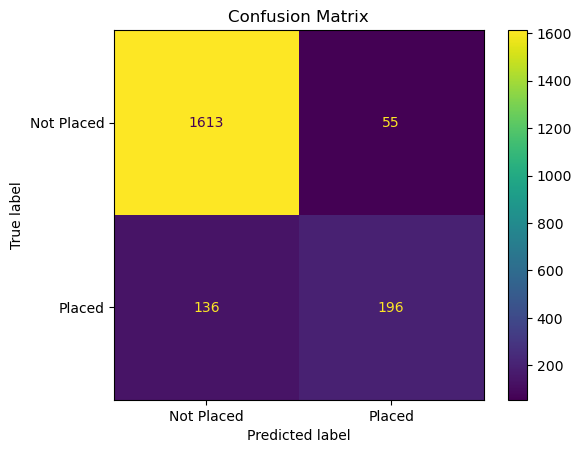

In [257]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix")
plt.show()

In [258]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_pred))

Accuracy: 0.9045

Confusion Matrix:
[[1613   55]
 [ 136  196]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      1668
           1       0.78      0.59      0.67       332

    accuracy                           0.90      2000
   macro avg       0.85      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000


ROC-AUC:
0.7786939123400075


In [259]:

import joblib
joblib.dump(model, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(x.columns.tolist(), "features.pkl")

['features.pkl']